

===== hyperelastic problem at iteration 0 =====
At Newton iteration 1 relative norm is 1.000000000000e+00
At Newton iteration 2 relative norm is 2.475010271093e+01
At Newton iteration 3 relative norm is 1.273855523642e+00
At Newton iteration 4 relative norm is 2.849304143712e-01
At Newton iteration 5 relative norm is 3.341643129411e-02
At Newton iteration 6 relative norm is 1.747338214557e-04
At Newton iteration 7 relative norm is 1.207942019896e-08
At Newton iteration 8 relative norm is 2.973907754750e-13


C:\Users\zacap\AppData\Local\Temp\ipykernel_23216\3239787574.py:63: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  PyVista.Plot_Mesh(simu).show()


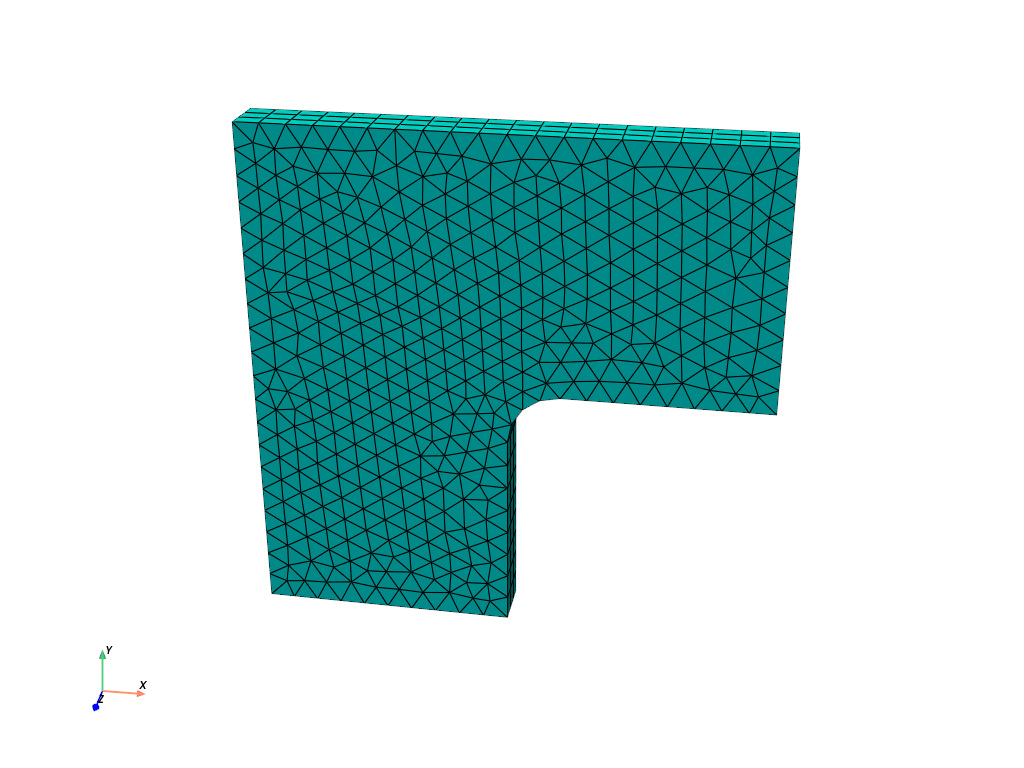

C:\Users\zacap\AppData\Local\Temp\ipykernel_23216\3239787574.py:64: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  PyVista.Plot_BoundaryConditions(simu).show()


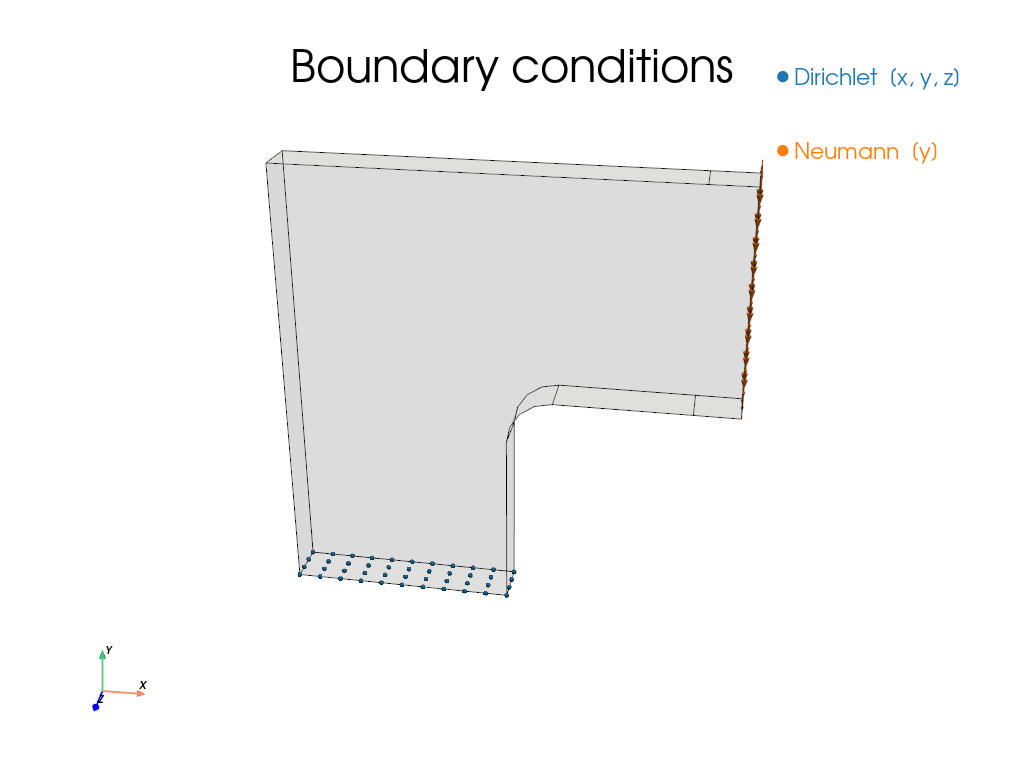

C:\Users\zacap\AppData\Local\Temp\ipykernel_23216\3239787574.py:65: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  PyVista.Plot(simu, "ux", deformFactor=1).show()


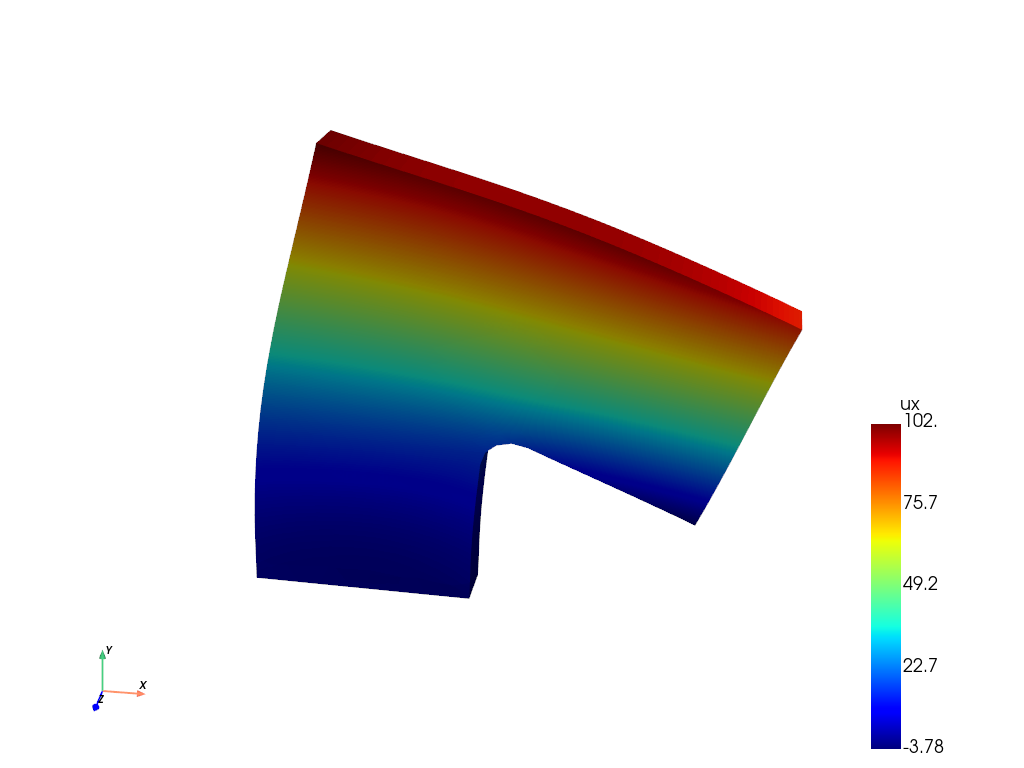

C:\Users\zacap\AppData\Local\Temp\ipykernel_23216\3239787574.py:66: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  PyVista.Plot(simu, "uy", deformFactor=1).show()


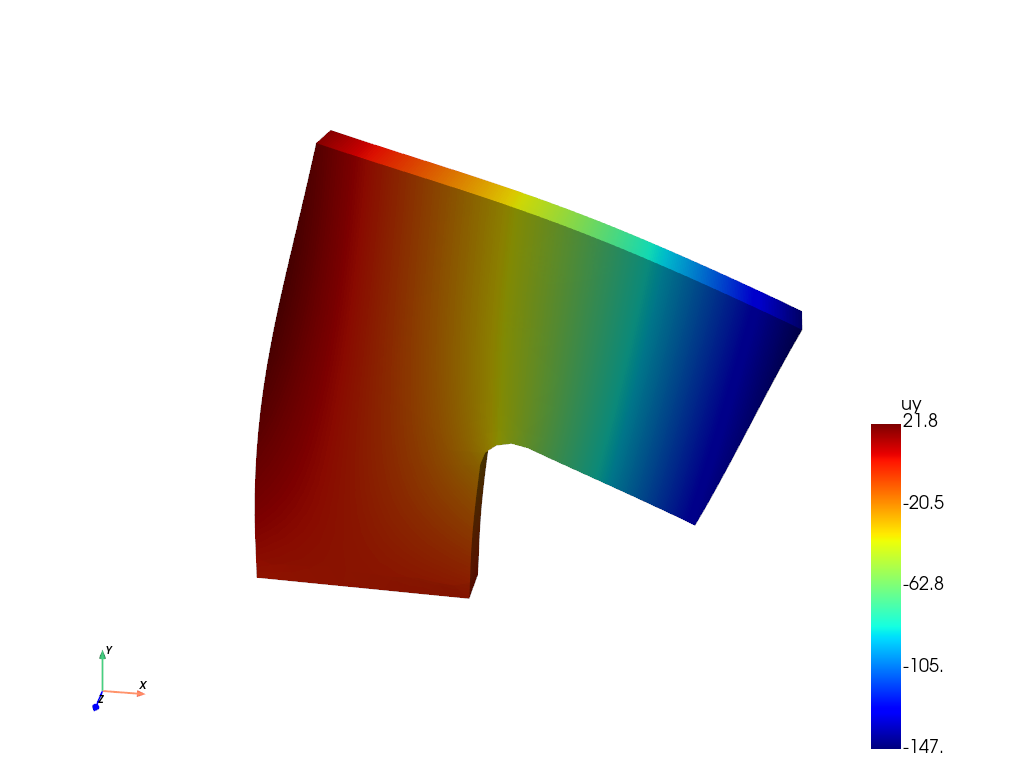



==================== Mesh ====================

elemType: PRISM6
Ne: 2370
Nn: 1744

==================== Model ====================


solver:scipy

============= Boundary Conditions =============

Unspecified.

=================== Results ===================

Unspecified.

=================== TicTac ===================

Mesh: 1.421 s
Boundary Conditions: 169.400 µs
Matrix: 21.372 s
Solver: 56.891 s
Resolution hyperelastic: 13.180 s
PyVista_Interface: 3.769 s


In [12]:
 from EasyFEA import Terminal, Models, ElemType, Simulations, PyVista
 from EasyFEA.Geoms import Point, Points

 if __name__ == "__main__":
     Terminal.Clear()

     # ----------------------------------------------
     # Configuration
     # ----------------------------------------------
     dim = 3

     # geom
     L = 250
     thickness = 50
     w = 50

     # load
     sigMax = -8 * 1e6 / (w * thickness)

     # ----------------------------------------------
     # Mesh
     # ----------------------------------------------
     meshSize = L / 10

     p1 = Point(0, 0)
     p2 = Point(L, 0)
     p3 = Point(L, L, r=50)
     p4 = Point(2 * L - w, L)
     p5 = Point(2 * L, L)
     p6 = Point(2 * L, 2 * L)
     p7 = Point(2 * L - w, 2 * L)
     p8 = Point(0, 2 * L)

     contour = Points([p1, p2, p3, p4, p5, p6, p7, p8], meshSize)

     if dim == 2:
         mesh = contour.Mesh_2D([], ElemType.QUAD8)
     else:
         mesh = contour.Mesh_Extrude([], [0, 0, -thickness], [3], ElemType.PRISM6)

     nodes_y0 = mesh.Nodes_Conditions(lambda x, y, z: y == 0)
     nodes_Load = mesh.Nodes_Conditions(lambda x, y, z: x == 2 * L)

     # ----------------------------------------------
     # Simulation
     # ----------------------------------------------
     elas = Models.Elastic.Isotropic(dim, E=300000, v=0.25, planeStress=True)
     material = Models.HyperElastic.SaintVenantKirchhoff(
         dim, elas.get_lambda(), elas.get_mu(), thickness=thickness
     )

     simu = Simulations.HyperElastic(mesh, material)

     simu.add_dirichlet(nodes_y0, [0] * dim, simu.Get_unknowns())
     simu.add_surfLoad(nodes_Load, [sigMax], ["y"])

     simu.Solve()

     # ----------------------------------------------
     # Results
     # ----------------------------------------------

     PyVista.Plot_Mesh(simu).show()
     PyVista.Plot_BoundaryConditions(simu).show()
     PyVista.Plot(simu, "ux", deformFactor=1).show()
     PyVista.Plot(simu, "uy", deformFactor=1).show()

     print(simu)